In [1]:
import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

print("=== Задача 1: Оптимизация производства электроники ===\n")

print("1.1. Математическая модель:")
print("Переменные: x1 - смартфоны, x2 - планшеты")
print("Целевая функция: P(x1, x2) = 8000*x1 + 12000*x2 -> max")
print("Ограничения:")
print("  2*x1 + 3*x2 <= 240 (процессорное время)")
print("  4*x1 + 6*x2 <= 480 (оперативная память)")
print("  1*x1 + 2*x2 <= 150 (аккумуляторы)")
print("  x1 >= 0, x2 >= 0\n")

print("1.2. Функция Лагранжа (для задачи минимизации -P):")
print("L(x, μ) = -8000*x1 - 12000*x2 + μ1*(2*x1 + 3*x2 - 240) + μ2*(4*x1 + 6*x2 - 480) + μ3*(x1 + 2*x2 - 150)")
print("Экономический смысл μ_i: теневая цена i-го ресурса (насколько увеличится прибыль при увеличении запаса ресурса на 1 единицу).\n")

c1 = [-8000, -12000]
A_ub1 = [[2, 3], [4, 6], [1, 2]]
b_ub1 = [240, 480, 150]
bounds1 = [(0, None), (0, None)]

res1 = linprog(c1, A_ub=A_ub1, b_ub=b_ub1, bounds=bounds1, method='highs')

print("1.3. и 1.5. Результаты решения:")
print(f"Статус: {res1.message}")
print(f"Оптимальное количество смартфонов (x1): {res1.x[0]}")
print(f"Оптимальное количество планшетов (x2): {res1.x[1]}")
print(f"Максимальная прибыль: {-res1.fun}")

=== Задача 1: Оптимизация производства электроники ===

1.1. Математическая модель:
Переменные: x1 - смартфоны, x2 - планшеты
Целевая функция: P(x1, x2) = 8000*x1 + 12000*x2 -> max
Ограничения:
  2*x1 + 3*x2 <= 240 (процессорное время)
  4*x1 + 6*x2 <= 480 (оперативная память)
  1*x1 + 2*x2 <= 150 (аккумуляторы)
  x1 >= 0, x2 >= 0

1.2. Функция Лагранжа (для задачи минимизации -P):
L(x, μ) = -8000*x1 - 12000*x2 + μ1*(2*x1 + 3*x2 - 240) + μ2*(4*x1 + 6*x2 - 480) + μ3*(x1 + 2*x2 - 150)
Экономический смысл μ_i: теневая цена i-го ресурса (насколько увеличится прибыль при увеличении запаса ресурса на 1 единицу).

1.3. и 1.5. Результаты решения:
Статус: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Оптимальное количество смартфонов (x1): 30.000000000000007
Оптимальное количество планшетов (x2): 60.0
Максимальная прибыль: 960000.0


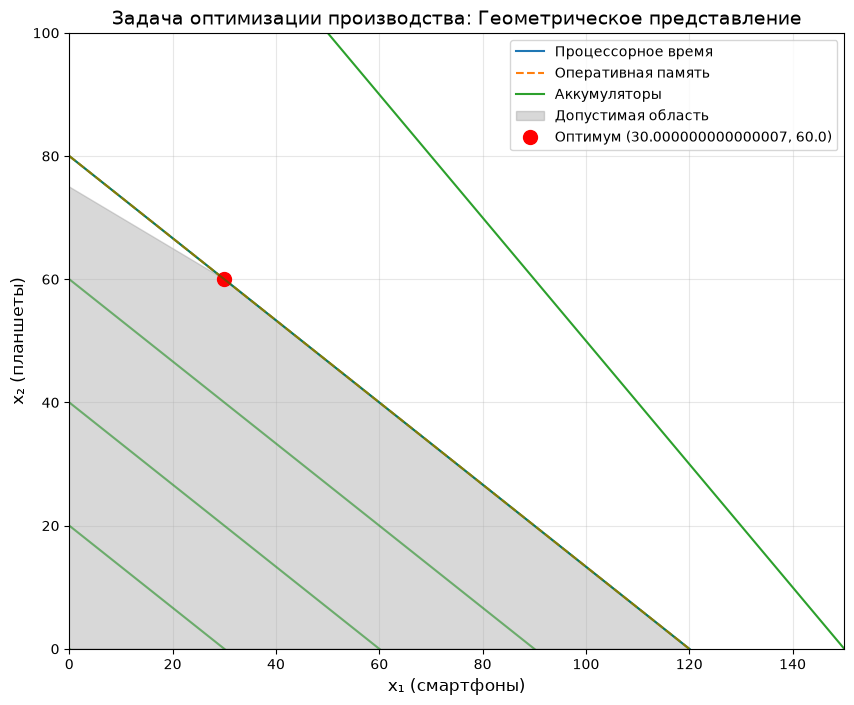

In [2]:
fig, ax = plt.subplots(figsize=(10, 8))
x1_vals = np.linspace(0, 150, 400)

x2_c1 = (240 - 2 * x1_vals) / 3
x2_c2 = (480 - 4 * x1_vals) / 6
x2_c3 = 150 - x1_vals

ax.plot(x1_vals, x2_c1, label='Процессорное время')
ax.plot(x1_vals, x2_c2, label='Оперативная память', linestyle='--')
ax.plot(x1_vals, x2_c3, label='Аккумуляторы')

vertices = [(0, 0), (120, 0), (30, 60), (0, 75)]
polygon = Polygon(vertices, closed=True, alpha=0.3, color='gray', label='Допустимая область')
ax.add_patch(polygon)

opt_x, opt_y = res1.x
ax.plot(opt_x, opt_y, 'ro', markersize=10, label=f'Оптимум ({opt_x}, {opt_y})')

for C in np.linspace(0, -res1.fun, 5):
    x2_iso = (C - 8000 * x1_vals) / 12000
    ax.plot(x1_vals, x2_iso, 'g-', alpha=0.5)

ax.set_xlim(0, 150)
ax.set_ylim(0, 100)
ax.set_xlabel('x₁ (смартфоны)', fontsize=12)
ax.set_ylabel('x₂ (планшеты)', fontsize=12)
ax.set_title('Задача оптимизации производства: Геометрическое представление', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [3]:
print("\n=== Задача 2: Оптимизация снабжения военных баз ===\n")

print("2.2. Проверка сбалансированности:")
supply = 150 + 250
demand = 120 + 180 + 100
print(f"Общий запас МТО: {supply} тонн")
print(f"Общая потребность баз: {demand} тонн")
print(f"Задача сбалансирована (закрыта): {supply == demand}\n")

print("2.3. Функция Лагранжа для транспортной задачи:")
print("L(x, λ, ν) = (8x11 + 6x12 + 10x13 + 9x21 + 7x22 + 5x23) +")
print("  λ1*(x11 + x12 + x13 - 150) + λ2*(x21 + x22 + x23 - 250) +")
print("  ν1*(x11 + x21 - 120) + ν2*(x12 + x22 - 180) + ν3*(x13 + x23 - 100)")
print("Смысл λ_i: ценность доп. тонны на складе. Смысл ν_j: стоимость доставки доп. тонны на базу.\n")

c2 = [8, 6, 10, 9, 7, 5]
A_eq2 = [
    [1, 1, 1, 0, 0, 0],
    [0, 0, 0, 1, 1, 1],
    [1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0],
    [0, 0, 1, 0, 0, 1]
]
b_eq2 = [150, 250, 120, 180, 100]
bounds2 = [(0, None)] * 6

res2 = linprog(c2, A_eq=A_eq2, b_eq=b_eq2, bounds=bounds2, method='highs')

print("2.4. Результаты решения:")
print(f"Статус: {res2.message}")
print("Оптимальный план перевозок (x11, x12, x13, x21, x22, x23):")
print(np.round(res2.x, 2))
print(f"Минимальная стоимость транспортировки: {res2.fun} у.е.")


=== Задача 2: Оптимизация снабжения военных баз ===

2.2. Проверка сбалансированности:
Общий запас МТО: 400 тонн
Общая потребность баз: 400 тонн
Задача сбалансирована (закрыта): True

2.3. Функция Лагранжа для транспортной задачи:
L(x, λ, ν) = (8x11 + 6x12 + 10x13 + 9x21 + 7x22 + 5x23) +
  λ1*(x11 + x12 + x13 - 150) + λ2*(x21 + x22 + x23 - 250) +
  ν1*(x11 + x21 - 120) + ν2*(x12 + x22 - 180) + ν3*(x13 + x23 - 100)
Смысл λ_i: ценность доп. тонны на складе. Смысл ν_j: стоимость доставки доп. тонны на базу.

2.4. Результаты решения:
Статус: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Оптимальный план перевозок (x11, x12, x13, x21, x22, x23):
[  0. 150.   0. 120.  30. 100.]
Минимальная стоимость транспортировки: 2690.0 у.е.


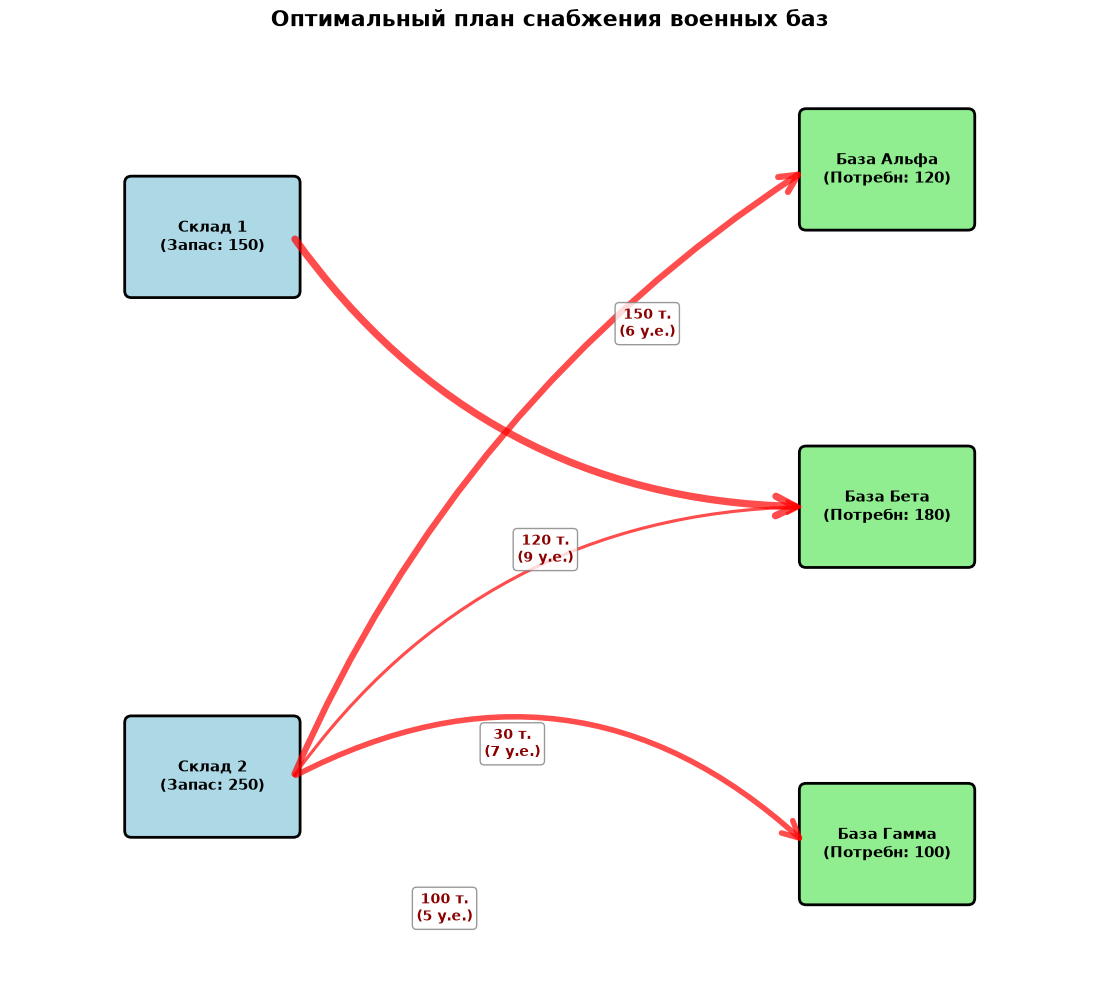

In [6]:
import numpy as np
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 10))

warehouses = {'Склад 1': (1, 9), 'Склад 2': (1, 1)}
bases = {'Альфа': (11, 10), 'Бета': (11, 5), 'Гамма': (11, 0)}

for name, (x, y) in warehouses.items():
    box = FancyBboxPatch((x-1.2, y-0.8), 2.4, 1.6, boxstyle="round,pad=0.1", 
                         edgecolor="black", facecolor="lightblue", linewidth=2)
    ax.add_patch(box)
    vol = 150 if name == 'Склад 1' else 250
    ax.text(x, y, f"{name}\n(Запас: {vol})", ha='center', va='center', fontsize=11, fontweight='bold')

for name, (x, y) in bases.items():
    box = FancyBboxPatch((x-1.2, y-0.8), 2.4, 1.6, boxstyle="round,pad=0.1", 
                         edgecolor="black", facecolor="lightgreen", linewidth=2)
    ax.add_patch(box)
    vol = {'Альфа': 120, 'Бета': 180, 'Гамма': 100}[name]
    ax.text(x, y, f"База {name}\n(Потребн: {vol})", ha='center', va='center', fontsize=11, fontweight='bold')

flows = [
    ('Склад 1', 'Альфа', res2.x[0], 8),
    ('Склад 1', 'Бета', res2.x[1], 6),
    ('Склад 1', 'Гамма', res2.x[2], 10),
    ('Склад 2', 'Альфа', res2.x[3], 9),
    ('Склад 2', 'Бета', res2.x[4], 7),
    ('Склад 2', 'Гамма', res2.x[5], 5)
]

edge_styles = {
    ('Склад 1', 'Альфа'): {'rad': 0.15, 'offset': 0.8},
    ('Склад 1', 'Бета'):  {'rad': 0.25, 'offset': 1.2},
    ('Склад 1', 'Гамма'): {'rad': 0.35, 'offset': 1.6},
    ('Склад 2', 'Альфа'): {'rad': -0.15, 'offset': -0.8},
    ('Склад 2', 'Бета'):  {'rad': -0.25, 'offset': -1.2},
    ('Склад 2', 'Гамма'): {'rad': -0.35, 'offset': -1.6}
}

for w_name, b_name, volume, cost in flows:
    if volume > 0.1:
        x_start, y_start = warehouses[w_name]
        x_end, y_end = bases[b_name]
        
        style = edge_styles[(w_name, b_name)]
        rad = style['rad']
        offset = style['offset']
        
        arrow = FancyArrowPatch(
            (x_start + 1.2, y_start), (x_end - 1.2, y_end),
            arrowstyle='->', mutation_scale=20 + volume / 10, 
            linewidth=1.5 + volume / 40, color='red', alpha=0.7,
            connectionstyle=f"arc3,rad={rad}"
        )
        ax.add_patch(arrow)
        
        mid_x = (x_start + x_end) / 2
        mid_y = (y_start + y_end) / 2
        
        dx = x_end - x_start
        dy = y_end - y_start
        length = np.hypot(dx, dy)
        
        if length > 0:
            nx = -dy / length
            ny = dx / length
            
            text_x = mid_x + nx * offset + rad * (x_end - x_start) * 0.4
            text_y = mid_y + ny * offset + rad * (y_end - y_start) * 0.4
        else:
            text_x, text_y = mid_x, mid_y
        
        ax.text(text_x, text_y, f"{volume:.0f} т.\n({cost} у.е.)", 
                ha='center', va='center', fontsize=10, color='darkred', fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

ax.set_xlim(-2, 14)
ax.set_ylim(-2, 12)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Оптимальный план снабжения военных баз', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()